# Classical ML Models - KNN, SVM, Random Forest

1. Load feature vectors (aggregated landmark sequences)
2. KNN - grid search + evaluation
3. SVM (linear) - grid search + evaluation
4. SVM (RBF) - grid search + evaluation
5. Random Forest - grid search + evaluation + feature importance
6. Compare all models

## 1. Load data
Aggregate each gesture's (T, 63) landmark sequence into a fixed-length feature vector (378 features).

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
from src.models.classical import load_features_and_labels, knn, svm_linear, svm_rbf, random_forest, measure_train_and_inference_time
from src.evaluation.metrics import full_evaluation, compare_models, CLASS_NAMES

In [2]:
X_train, y_train = load_features_and_labels("../data/landmarks/train/_metadata.csv")
X_test, y_test = load_features_and_labels("../data/landmarks/test/_metadata.csv")
print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_test:", X_test.shape, " y_test:", y_test.shape)

X_train: (3115, 378)  y_train: (3115,)
X_test: (1101, 378)  y_test: (1101,)


In [3]:
print("NaN in X_train:", np.isnan(X_train).sum())
print("Inf in X_train:", np.isinf(X_train).sum())
print("NaN in X_test:", np.isnan(X_test).sum())
print("Inf in X_test:", np.isinf(X_test).sum())

NaN in X_train: 0
Inf in X_train: 0
NaN in X_test: 0
Inf in X_test: 0


## 2. KNN
Grid search over k (3-21) and distance metric (Euclidean, Manhattan, Minkowski), with `StandardScaler` and 5-fold stratified CV.

In [4]:
knn_search = knn(X_train, y_train)

Best params: {'knn__metric': 'euclidean', 'knn__n_neighbors': 3}
Best CV F1 (weighted): 0.6994


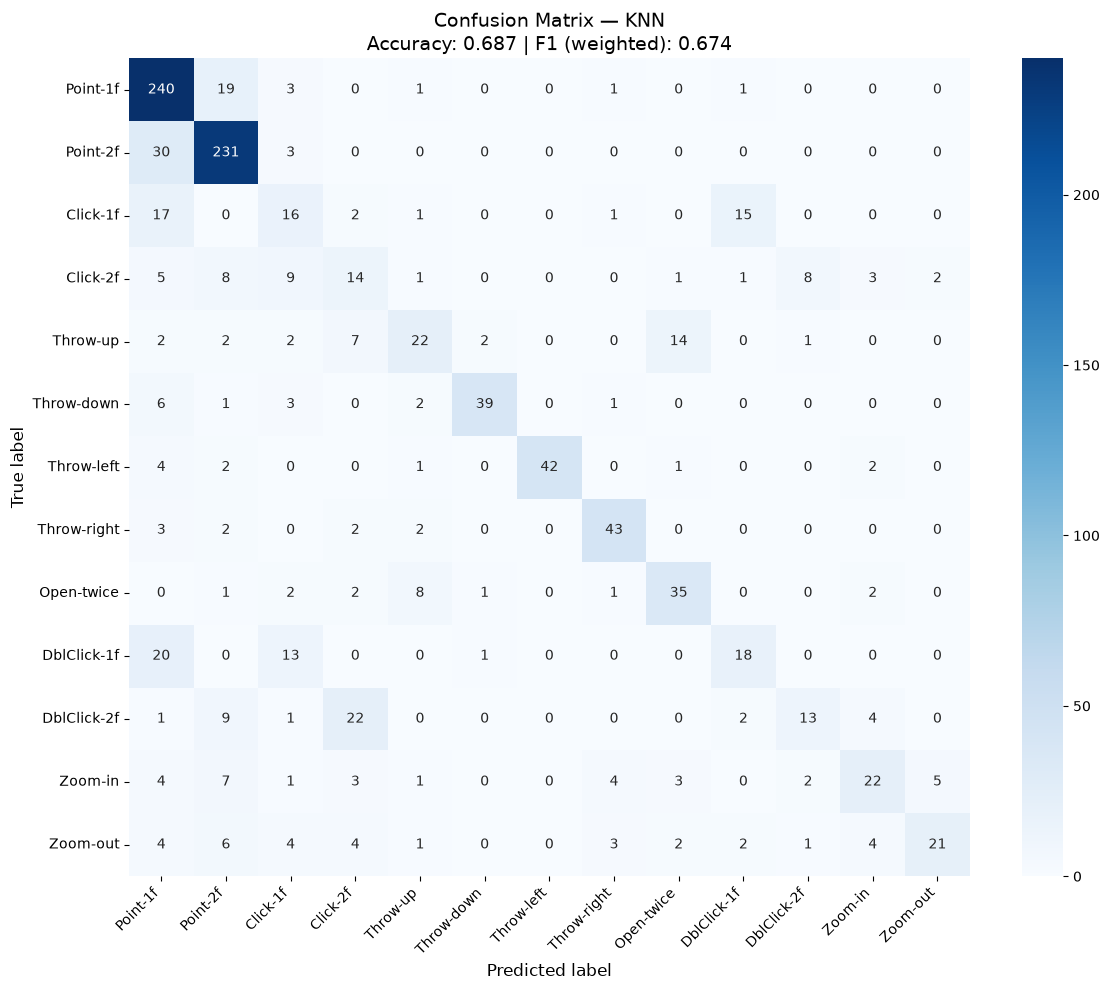

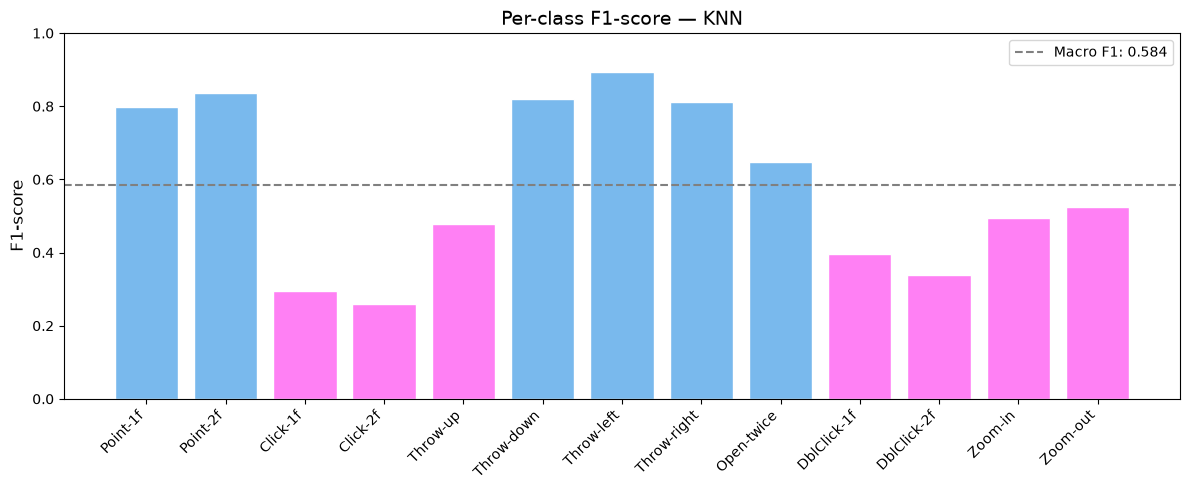


  KNN — Results
  Accuracy:          0.6866
  F1 (weighted):     0.6743
  F1 (macro):        0.5841
  Precision (w):     0.6823
  Recall (w):        0.6866
  Top-3 Accuracy:    0.8710
  Top-5 Accuracy:    0.9010

              precision    recall  f1-score   support

    Point-1f       0.71      0.91      0.80       265
    Point-2f       0.80      0.88      0.84       264
    Click-1f       0.28      0.31      0.29        52
    Click-2f       0.25      0.27      0.26        52
    Throw-up       0.55      0.42      0.48        52
  Throw-down       0.91      0.75      0.82        52
  Throw-left       1.00      0.81      0.89        52
 Throw-right       0.80      0.83      0.81        52
  Open-twice       0.62      0.67      0.65        52
 DblClick-1f       0.46      0.35      0.40        52
 DblClick-2f       0.52      0.25      0.34        52
     Zoom-in       0.59      0.42      0.49        52
    Zoom-out       0.75      0.40      0.53        52

    accuracy                

In [17]:
y_pred_knn = knn_search.predict(X_test)
y_prob_knn = knn_search.predict_proba(X_test)

knn_results = full_evaluation(
    y_test, y_pred_knn, model_name="KNN", y_prob=y_prob_knn,
    save_dir="../results/figures/classical_models"
)

knn_timing = measure_train_and_inference_time(
    knn_search.best_estimator_, X_train, y_train, X_test
)
knn_results.update(knn_timing)
print(knn_timing)

all_results = [knn_results]

## 3. SVM (linear)
Grid search over C (0.01-100) with `StandardScaler` and 5-fold stratified CV.

In [7]:
svm_linear_search = svm_linear(X_train, y_train)

/home/teodora/Desktop/video-hand-gesture-recognition/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/teodora/Desktop/video-hand-gesture-recognition/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/teodora/Desktop/video-hand-gesture-recognition/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/teodora/Desktop/video-hand-gesture

Best params: {'svm__C': 0.1}
Best CV F1 (weighted): 0.8224


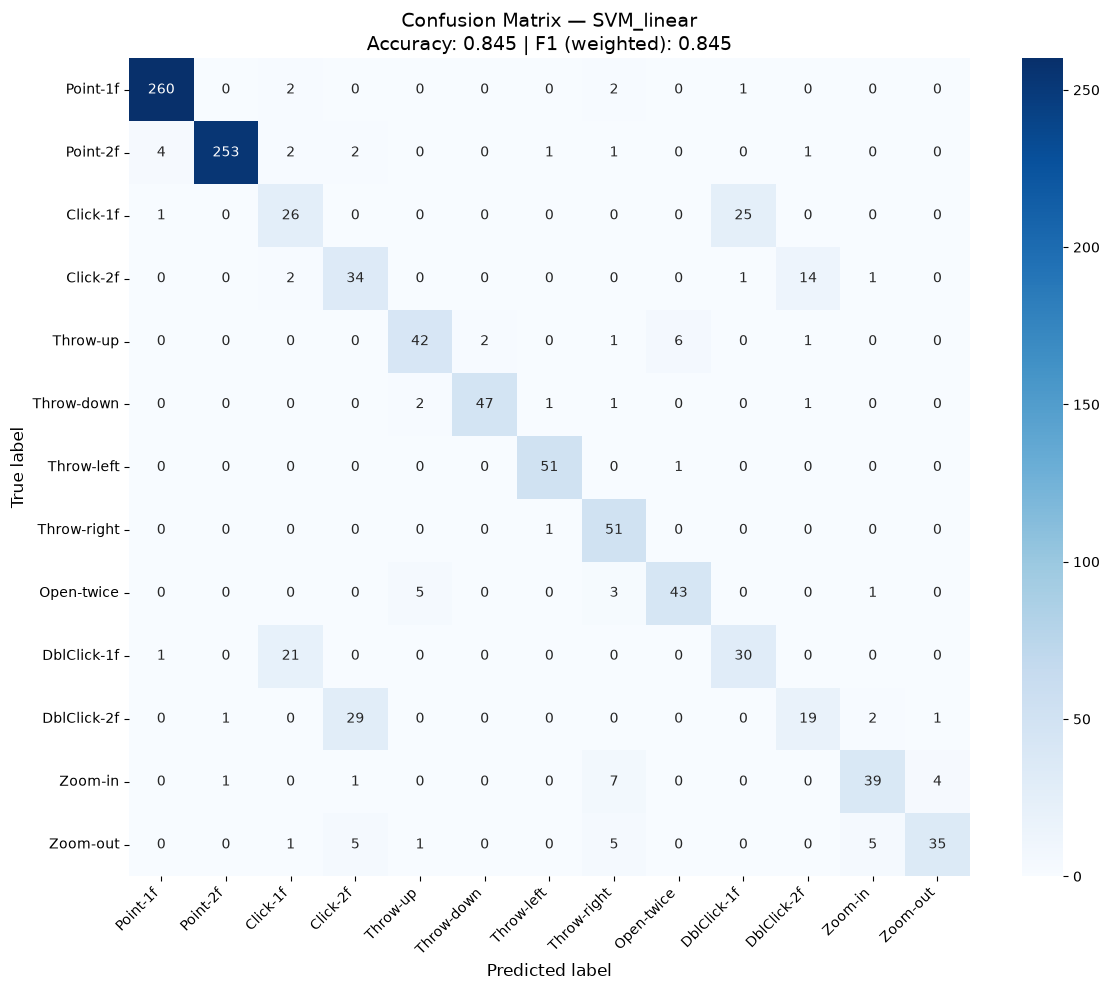

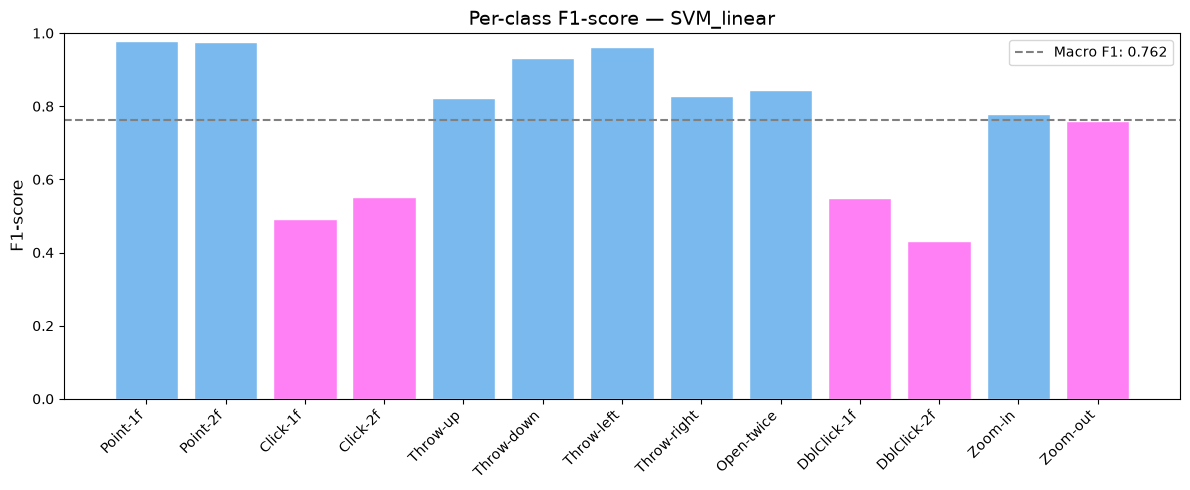


  SVM_linear — Results
  Accuracy:          0.8447
  F1 (weighted):     0.8452
  F1 (macro):        0.7623
  Precision (w):     0.8521
  Recall (w):        0.8447
  Top-3 Accuracy:    0.9846
  Top-5 Accuracy:    0.9909

              precision    recall  f1-score   support

    Point-1f       0.98      0.98      0.98       265
    Point-2f       0.99      0.96      0.97       264
    Click-1f       0.48      0.50      0.49        52
    Click-2f       0.48      0.65      0.55        52
    Throw-up       0.84      0.81      0.82        52
  Throw-down       0.96      0.90      0.93        52
  Throw-left       0.94      0.98      0.96        52
 Throw-right       0.72      0.98      0.83        52
  Open-twice       0.86      0.83      0.84        52
 DblClick-1f       0.53      0.58      0.55        52
 DblClick-2f       0.53      0.37      0.43        52
     Zoom-in       0.81      0.75      0.78        52
    Zoom-out       0.88      0.67      0.76        52

    accuracy         

/home/teodora/Desktop/video-hand-gesture-recognition/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


{'train_time_s': 3.1418029529995692, 'inference_mean_ms': 1.2772135299746878, 'inference_std_ms': 0.5131861765907083, 'inference_fps': 782.9544367728538}


In [18]:
y_pred_svm_lin = svm_linear_search.predict(X_test)
y_prob_svm_lin = svm_linear_search.predict_proba(X_test)

svm_linear_results = full_evaluation(
    y_test, y_pred_svm_lin, model_name="SVM_linear", y_prob=y_prob_svm_lin,
    save_dir="../results/figures/classical_models"
)

svm_linear_timing = measure_train_and_inference_time(
    svm_linear_search.best_estimator_, X_train, y_train, X_test
)
svm_linear_results.update(svm_linear_timing)
print(svm_linear_timing)

all_results.append(svm_linear_results)

## 4. SVM (RBF kernel)
Grid search over C (0.1-100) and gamma (0.001-1, 'scale') with `StandardScaler` and 5-fold stratified CV.

In [11]:
svm_rbf_search = svm_rbf(X_train, y_train)

/home/teodora/Desktop/video-hand-gesture-recognition/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/teodora/Desktop/video-hand-gesture-recognition/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/teodora/Desktop/video-hand-gesture-recognition/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/teodora/Desktop/video-hand-gesture

Best params: {'svm__C': 100, 'svm__gamma': 0.001}
Best CV F1 (weighted): 0.8248


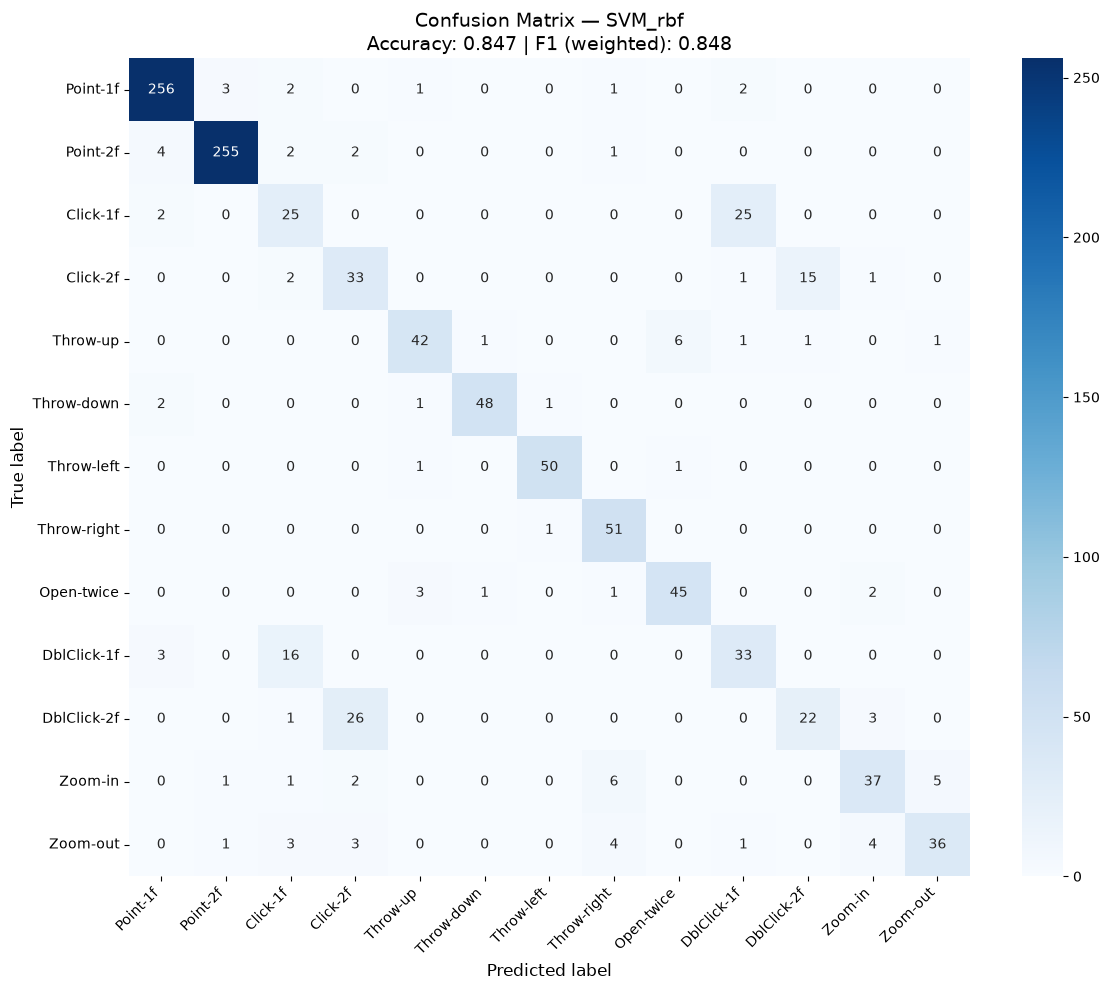

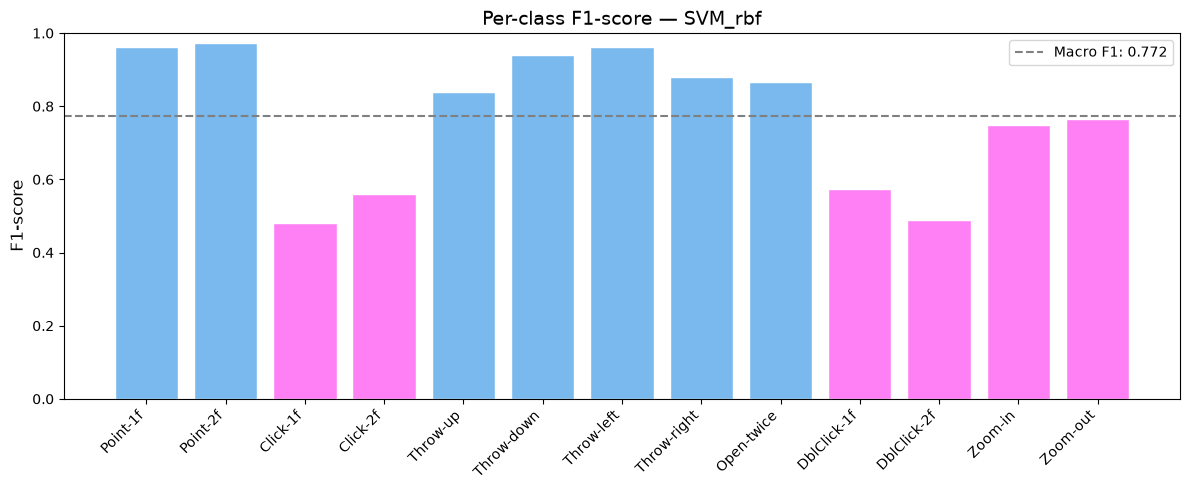


  SVM_rbf — Results
  Accuracy:          0.8474
  F1 (weighted):     0.8478
  F1 (macro):        0.7723
  Precision (w):     0.8526
  Recall (w):        0.8474
  Top-3 Accuracy:    0.9764
  Top-5 Accuracy:    0.9918

              precision    recall  f1-score   support

    Point-1f       0.96      0.97      0.96       265
    Point-2f       0.98      0.97      0.97       264
    Click-1f       0.48      0.48      0.48        52
    Click-2f       0.50      0.63      0.56        52
    Throw-up       0.88      0.81      0.84        52
  Throw-down       0.96      0.92      0.94        52
  Throw-left       0.96      0.96      0.96        52
 Throw-right       0.80      0.98      0.88        52
  Open-twice       0.87      0.87      0.87        52
 DblClick-1f       0.52      0.63      0.57        52
 DblClick-2f       0.58      0.42      0.49        52
     Zoom-in       0.79      0.71      0.75        52
    Zoom-out       0.86      0.69      0.77        52

    accuracy            

/home/teodora/Desktop/video-hand-gesture-recognition/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


{'train_time_s': 3.117516202997649, 'inference_mean_ms': 1.149845650070347, 'inference_std_ms': 0.3627662653987068, 'inference_fps': 869.6819437798634}


In [21]:
y_pred_svm_rbf = svm_rbf_search.predict(X_test)
y_prob_svm_rbf = svm_rbf_search.predict_proba(X_test)

svm_rbf_results = full_evaluation(
    y_test, y_pred_svm_rbf, model_name="SVM_rbf", y_prob=y_prob_svm_rbf,
    save_dir="../results/figures/classical_models"
)

svm_rbf_timing = measure_train_and_inference_time(
    svm_rbf_search.best_estimator_, X_train, y_train, X_test
)
svm_rbf_results.update(svm_rbf_timing)
print(svm_rbf_timing)

all_results.append(svm_rbf_results)

## 5. Random Forest
Grid search over n_estimators (50-500), max_depth (None, 10, 20, 30), min_samples_split (2, 5, 10) with 5-fold stratified CV.

In [13]:
rf_search = random_forest(X_train, y_train)

Best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 (weighted): 0.7831


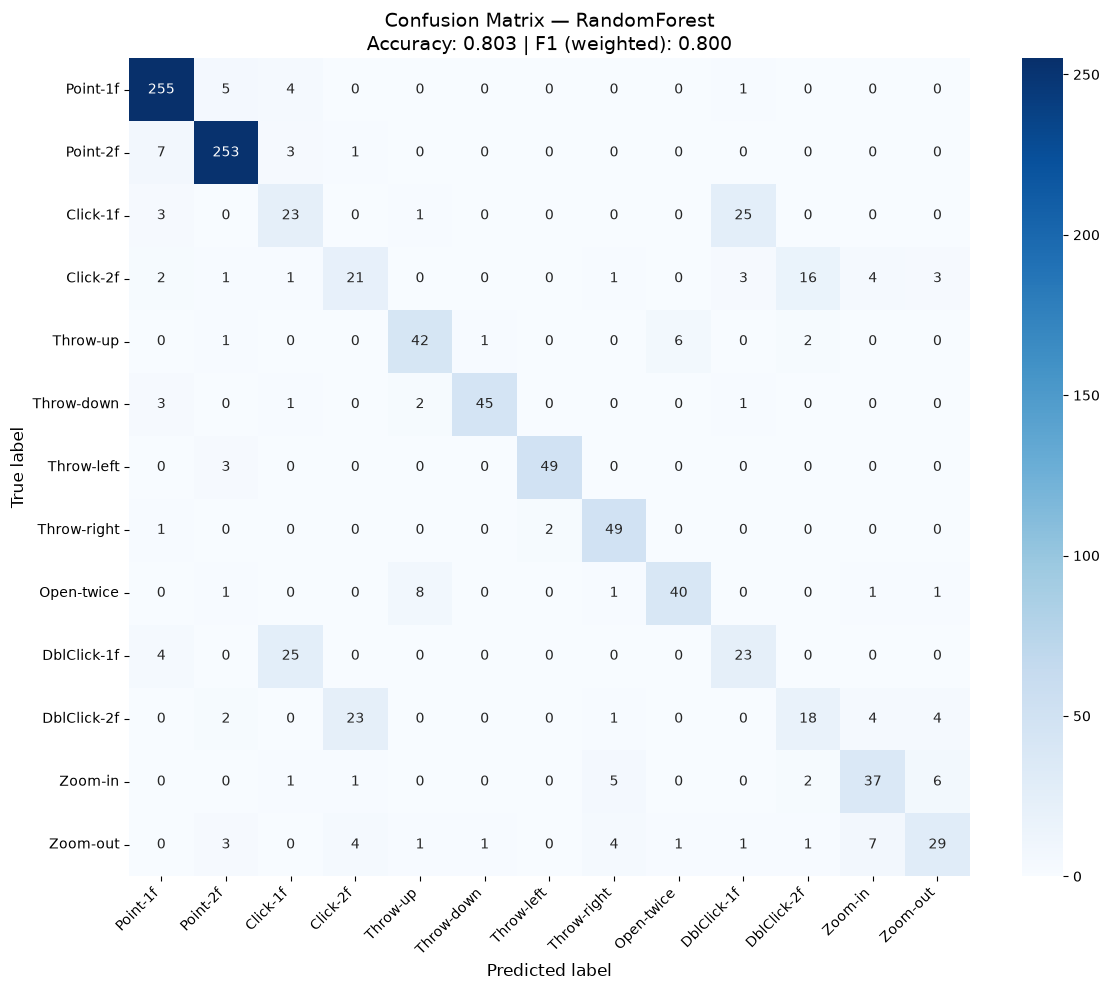

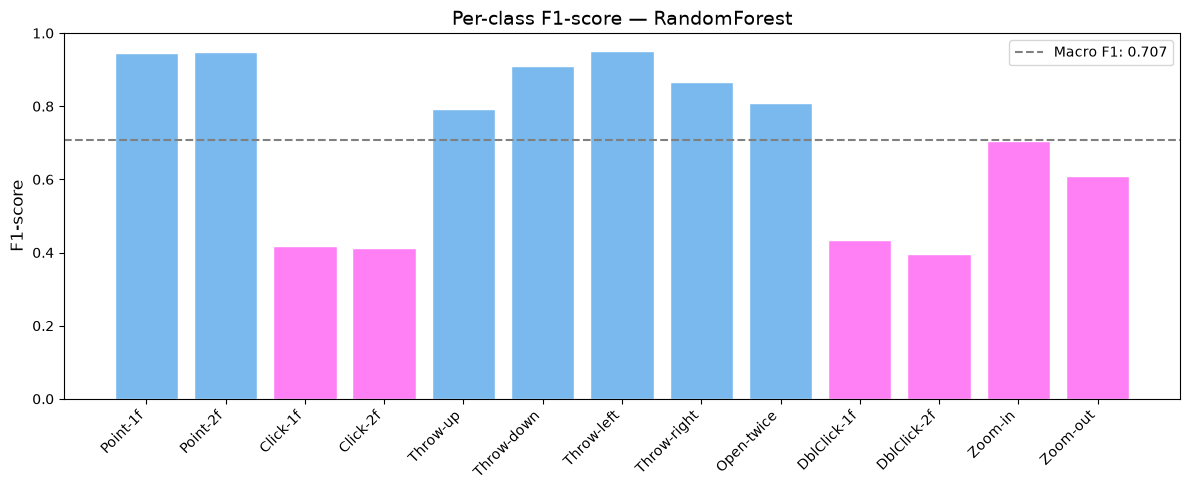


  RandomForest — Results
  Accuracy:          0.8029
  F1 (weighted):     0.7999
  F1 (macro):        0.7075
  Precision (w):     0.7995
  Recall (w):        0.8029
  Top-3 Accuracy:    0.9555
  Top-5 Accuracy:    0.9864

              precision    recall  f1-score   support

    Point-1f       0.93      0.96      0.94       265
    Point-2f       0.94      0.96      0.95       264
    Click-1f       0.40      0.44      0.42        52
    Click-2f       0.42      0.40      0.41        52
    Throw-up       0.78      0.81      0.79        52
  Throw-down       0.96      0.87      0.91        52
  Throw-left       0.96      0.94      0.95        52
 Throw-right       0.80      0.94      0.87        52
  Open-twice       0.85      0.77      0.81        52
 DblClick-1f       0.43      0.44      0.43        52
 DblClick-2f       0.46      0.35      0.40        52
     Zoom-in       0.70      0.71      0.70        52
    Zoom-out       0.67      0.56      0.61        52

    accuracy       

In [20]:
y_pred_rf = rf_search.predict(X_test)
y_prob_rf = rf_search.predict_proba(X_test)

rf_results = full_evaluation(
    y_test, y_pred_rf, model_name="RandomForest", y_prob=y_prob_rf,
    save_dir="../results/figures/classical_models"
)

rf_timing = measure_train_and_inference_time(
    rf_search.best_estimator_, X_train, y_train, X_test
)
rf_results.update(rf_timing)
print(rf_timing)

all_results.append(rf_results)

### Feature importance
Shows the top-20 most important landmark features - which coordinates matter most for telling gestures apart.

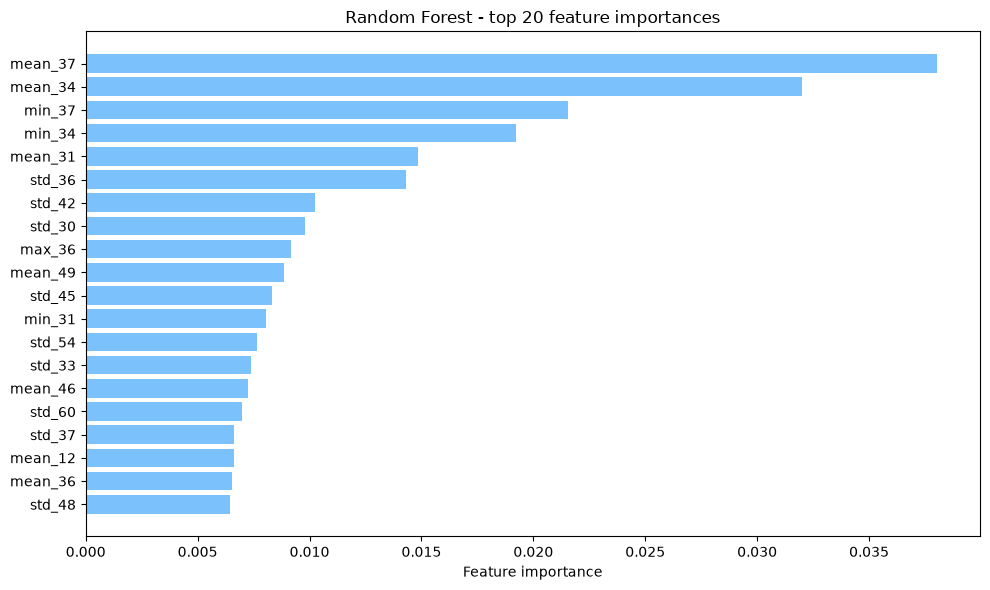

In [15]:
import matplotlib.pyplot as plt

best_rf = rf_search.best_estimator_
importances = best_rf.feature_importances_

# Feature vector layout: mean(63), std(63), min(63), max(63), vel_mean(63), vel_std(63)
stat_names = ['mean', 'std', 'min', 'max', 'vel_mean', 'vel_std']
feature_labels = [f"{stat}_{i}" for stat in stat_names for i in range(63)]

top_idx = np.argsort(importances)[::-1][:20]
top_importances = importances[top_idx]
top_labels = [feature_labels[i] for i in top_idx]

plt.figure(figsize=(10, 6))
plt.barh(range(20), top_importances[::-1], color="#7BC1FB")
plt.yticks(range(20), top_labels[::-1])
plt.xlabel("Feature importance")
plt.title("Random Forest - top 20 feature importances")
plt.tight_layout()
plt.savefig("../results/figures/classical_models/rf_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Compare all models
Side-by-side comparison of accuracy, weighted F1, and macro F1 across KNN, SVM (linear), SVM (RBF), and Random Forest.

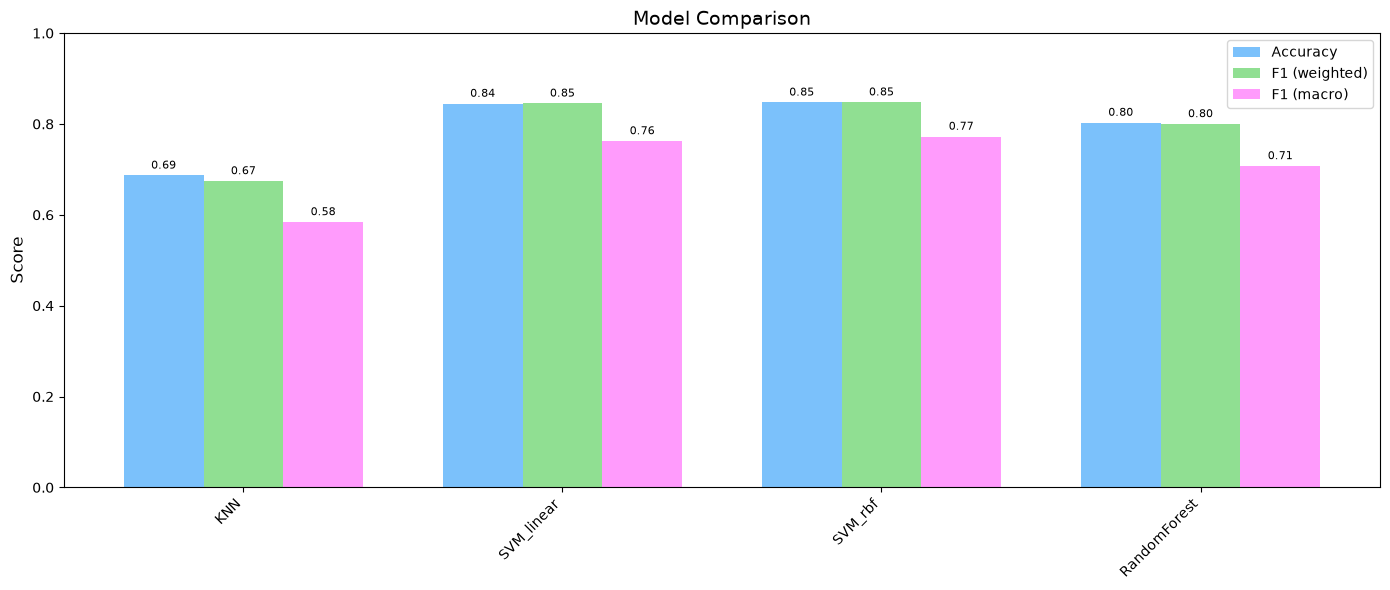


  FINAL MODEL COMPARISON
  Model                       Accuracy     F1 (w)     F1 (m)
  -------------------------------------------------------
  SVM_rbf                       0.8474     0.8478     0.7723
  SVM_linear                    0.8447     0.8452     0.7623
  RandomForest                  0.8029     0.7999     0.7075
  KNN                           0.6866     0.6743     0.5841



In [16]:
compare_models(all_results, save_dir="../results/figures/classical_models")